In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger le fichier Excel
df = pd.read_excel("C:/Users/Utilisateur/Documents/spotify/final.xlsx")

# Afficher un aperçu
df.head()

,date,streams,explicit,country,region,min,main_genre
0,2022-11-10,280161,False,Australia,Pacific,4.123767,Pop & Mainstream
1,2022-11-10,280161,False,Australia,Pacific,4.123767,Pop & Mainstream
2,2022-11-10,280161,False,Australia,Pacific,4.123767,Pop & Mainstream
3,2022-11-10,280161,False,Australia,Pacific,4.123767,Pop & Mainstream
4,2022-11-10,280161,False,Australia,Pacific,4.123767,Electronic / Dance / EDM


In [6]:
df.columns

Index(['date', 'streams', 'explicit', 'country', 'region', 'min',
       'main_genre'],
      dtype='object')

In [7]:
# Grouper par region et genre et calculer la moyenne des streams
heatmap_data = df.groupby(['region', 'main_genre'])['streams'].mean().reset_index()

# Transformer pour que les genres soient les colonnes et les régions les lignes
heatmap_pivot = heatmap_data.pivot(index='region', columns='main_genre', values='streams')

# Afficher le pivot pour vérifier
print(heatmap_pivot)

main_genre                   Asian Pop & Regional Genres  \
region                                                     
Afrique                                              NaN   
Amérique Latine et Centrale                          NaN   
Amérique du Nord                                     NaN   
Asie                                       361307.050955   
Europe                                     723295.000000   
Orient/Moyen-Orient                                  NaN   
Pacifique                                            NaN   

main_genre                   Electronic / Dance / EDM           Folk  \
region                                                                 
Afrique                                 136420.416667   48383.571429   
Amérique Latine et Centrale             889367.000000            NaN   
Amérique du Nord                        912552.800000            NaN   
Asie                                    245371.547619            NaN   
Europe                     

In [27]:
import numpy as np
# Pivot
heatmap_pivot = heatmap_data.pivot(index='region', columns='main_genre', values='streams')

# Garder les genres présents dans tous les pays
genres_complets = heatmap_pivot.dropna(axis=1)

# Logarithme pour lisser les grosses valeurs
heatmap_smoothed = np.log1p(genres_complets)

# Vérifier le résultat
print(heatmap_smoothed)

main_genre                   Electronic / Dance / EDM  Hip Hop & Rap  \
region                                                                 
Africa                                      11.823504      11.285330   
Asia                                        12.410533      13.883898   
Central and Souther America                 13.698266      13.451201   
Europa                                      13.469231      13.807580   
Middle East                                 10.051062      11.237147   
North America du Nord                       13.724002      15.389425   
Pacific                                     12.836248      13.228905   

main_genre                       Other  Pop & Mainstream  
region                                                    
Africa                       11.693122         11.233531  
Asia                         13.370907         12.922198  
Central and Souther America  14.248296         13.794326  
Europa                       13.396460         13.453109

In [20]:
# Remplir NaN par la moyenne du genre
heatmap_filled = heatmap_pivot.fillna(heatmap_pivot.mean())

In [21]:
# Limiter les valeurs aux percentiles 5% et 95%
lower = heatmap_filled.quantile(0.05)
upper = heatmap_filled.quantile(0.95)
heatmap_clipped = heatmap_filled.clip(lower=lower, upper=upper, axis=1)

In [22]:
import numpy as np

# Log pour lisser
heatmap_smoothed = np.log1p(heatmap_clipped)
# Ou z-score
heatmap_zscore = (heatmap_clipped - heatmap_clipped.mean()) / heatmap_clipped.std()

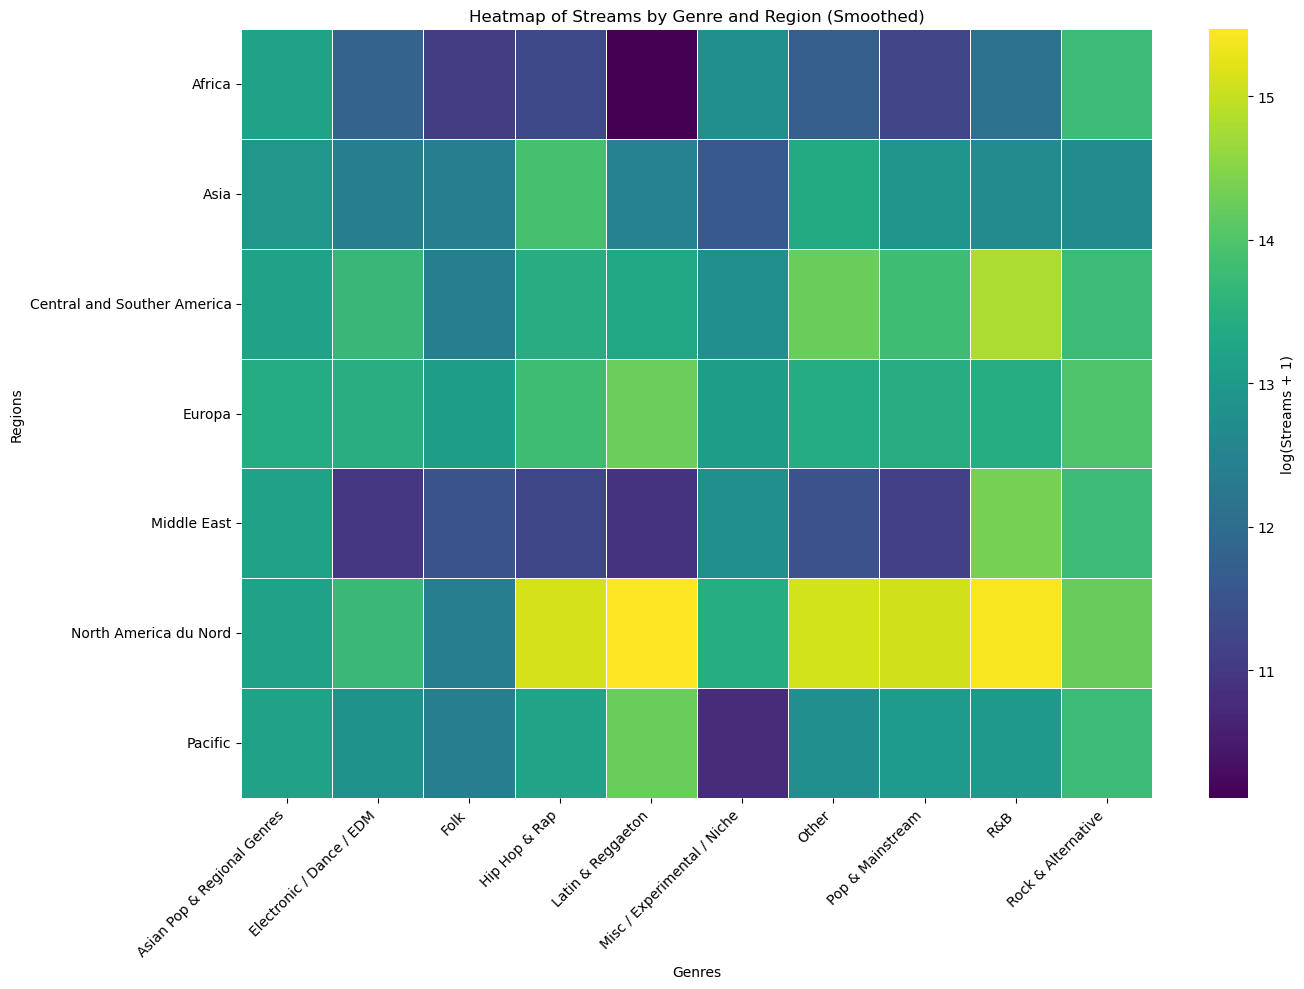

In [39]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_smoothed, 
    cmap='viridis', 
    linewidths=0.5,
    cbar_kws={'label': 'log(Streams + 1)'}
)

plt.title("Heatmap of Streams by Genre and Region (Smoothed)")
plt.xlabel("Genres")
plt.ylabel("Regions")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# ✅ Save the figure BEFORE showing it
plt.savefig("heatmap_genres.png", dpi=300)

plt.show()

In the heatmap, some songs or genres have very high numbers of streams while others have much lower numbers. To make the differences easier to see, we apply a logarithmic smoothing (log(Streams + 1)). This doesn’t change the order — the most streamed genres stay the brightest — but it compresses very large numbers so they don’t overwhelm the smaller ones. As a result, the heatmap clearly shows variations across all genres and regions, making it easier to compare popularity without a few huge hits dominating the colors. This visualization is an experimental approach to explore trends and relative differences in streaming data.

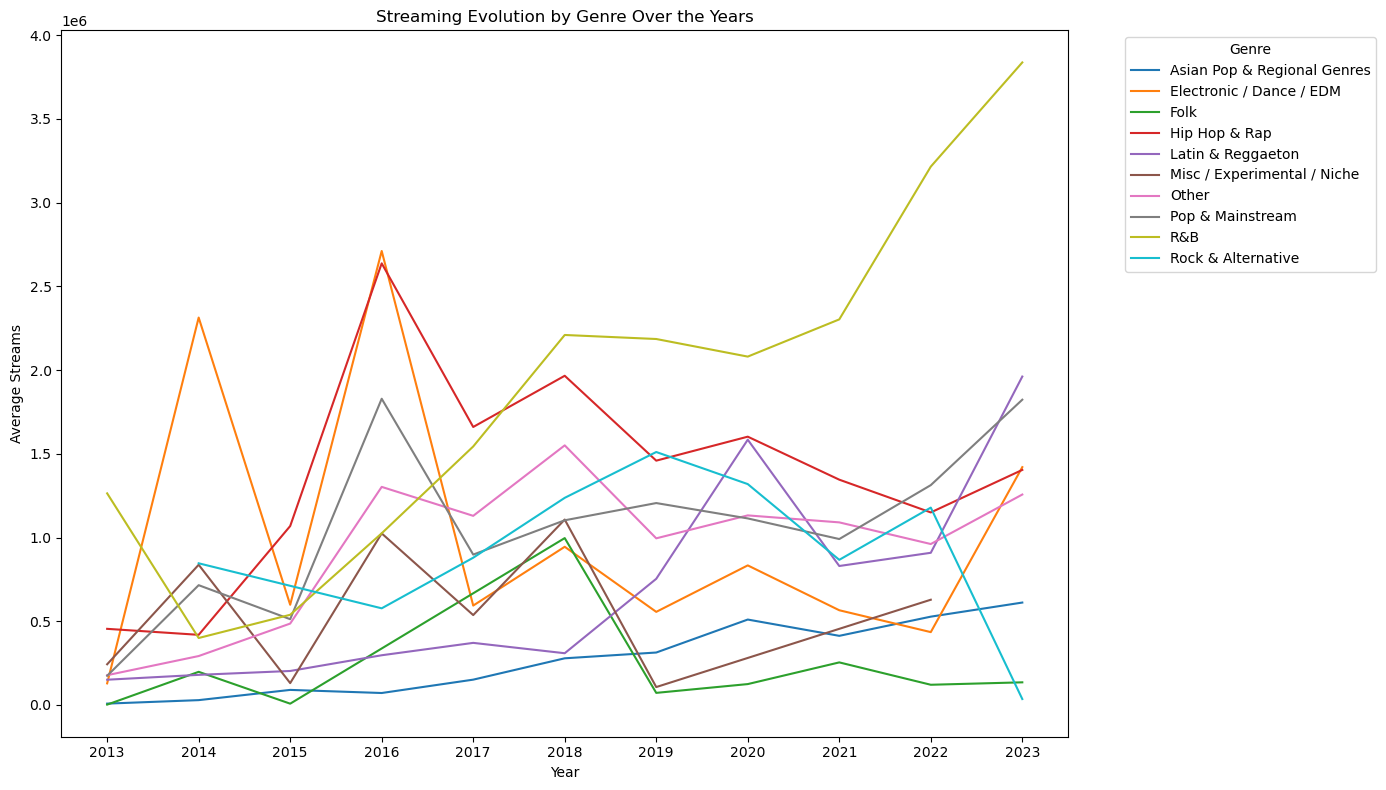

In [34]:
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=yearly_genre,
    x='year',
    y='streams',
    hue='main_genre'
)

plt.title("Streaming Evolution by Genre Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Streams")
plt.xticks(yearly_genre['year'].sort_values().unique())
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# ✅ Save as PNG
plt.savefig("C:/Users/Utilisateur/Desktop/lineplot_genres.png", dpi=300)  # dpi=300 gives high quality


plt.show()

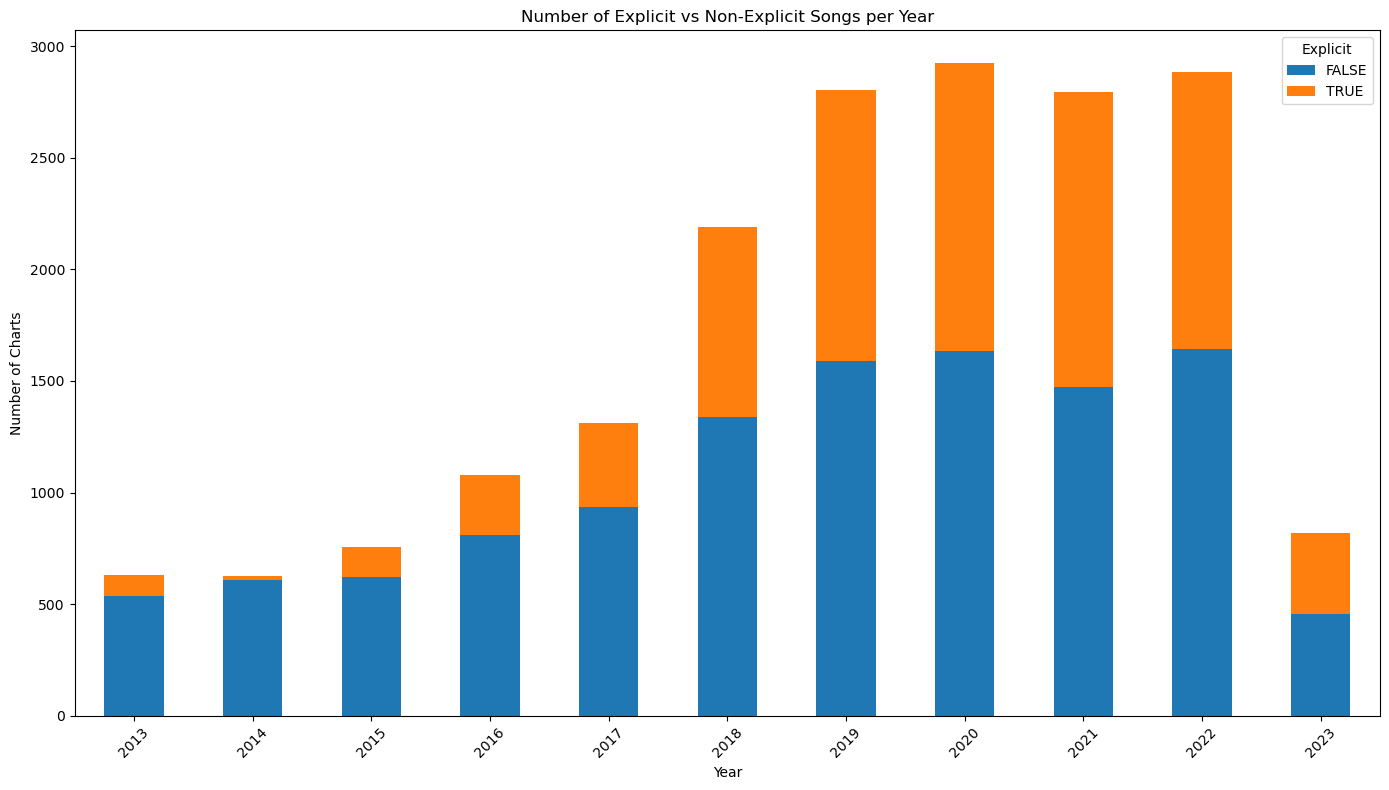

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Convert 'date' column to datetime if needed
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['year'] = df['date'].dt.year

# 2️⃣ Count of explicit True/False per year
explicit_counts = df.groupby(['year', 'explicit']).size().unstack(fill_value=0)

# 3️⃣ Plot stacked bar chart
explicit_counts.plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 8),
    color=['#1f77b4', '#ff7f0e']  # optional: blue for FALSE, orange for TRUE
)

plt.title("Number of Explicit vs Non-Explicit Songs per Year")
plt.xlabel("Year")
plt.ylabel("Number of Charts")
plt.xticks(rotation=45)
plt.legend(title='Explicit', labels=['FALSE', 'TRUE'])
plt.tight_layout()

# ✅ Save figure as PNG if needed
plt.savefig("explicit_barchart.png", dpi=300)

plt.show()

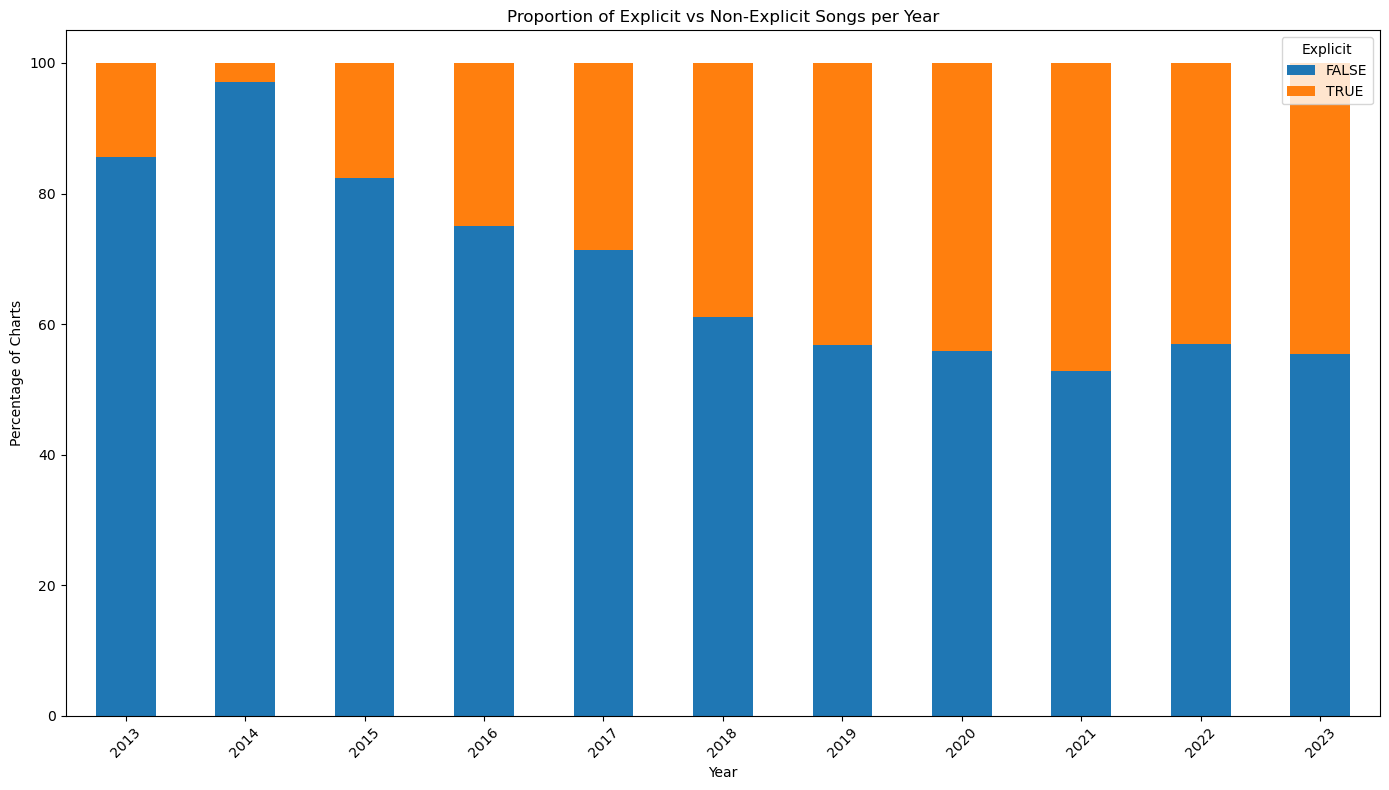

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Convert 'date' to datetime and extract year
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['year'] = df['date'].dt.year

# 2️⃣ Count explicit True/False per year
explicit_counts = df.groupby(['year', 'explicit']).size().unstack(fill_value=0)

# 3️⃣ Convert counts to percentages
explicit_percent = explicit_counts.div(explicit_counts.sum(axis=1), axis=0) * 100

# 4️⃣ Plot stacked bar chart in percentages
explicit_percent.plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 8),
    color=['#1f77b4', '#ff7f0e']  # blue = FALSE, orange = TRUE
)

plt.title("Proportion of Explicit vs Non-Explicit Songs per Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Charts")  # ✅ updated label
plt.xticks(rotation=45)
plt.legend(title='Explicit', labels=['FALSE', 'TRUE'])
plt.tight_layout()

# Save figure if needed
plt.savefig("explicit_percent_barchart.png", dpi=300)

plt.show()

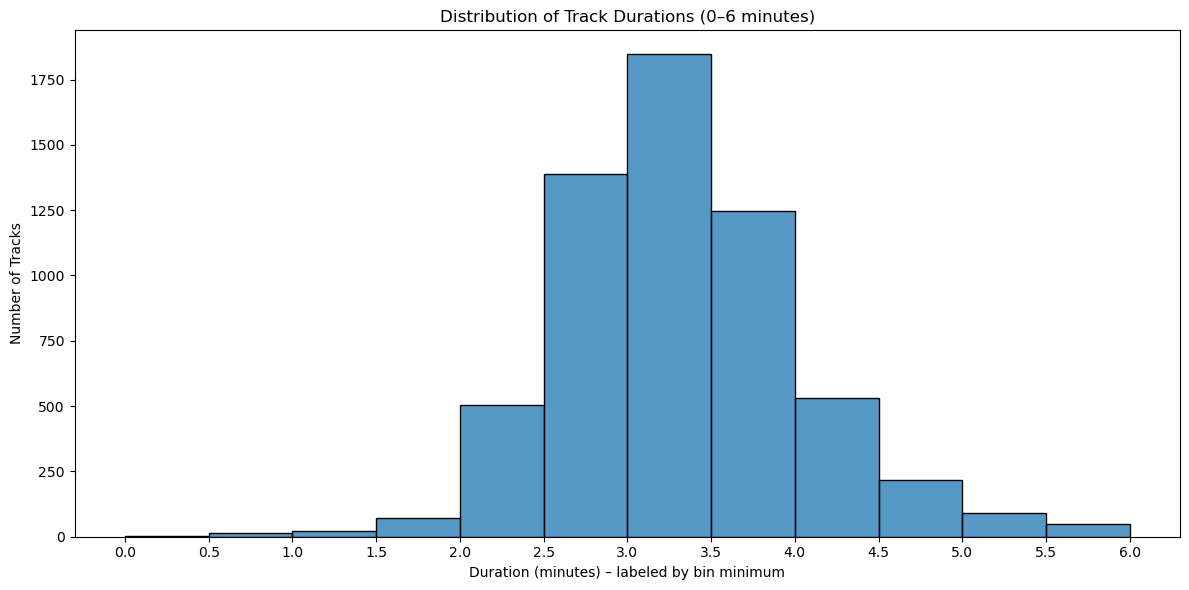

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1️⃣ Load Excel file
df_tracks = pd.read_excel("track.xlsx")  # Make sure the file is in your working directory

# 2️⃣ Filter durations to only include 0–6 minutes
durations_filtered = df_tracks['duration'].dropna()
durations_filtered = durations_filtered[(durations_filtered >= 0) & (durations_filtered <= 6)]

# 3️⃣ Define bins from 0 to 6 minutes in 0.5 increments
bins = np.arange(0, 6.5, 0.5)  # 0, 0.5, 1, ..., 6

# 4️⃣ Plot histogram
plt.figure(figsize=(12,6))
sns.histplot(
    durations_filtered,
    bins=bins,
    color='#1f77b4'
)

plt.title("Distribution of Track Durations (0–6 minutes)")
plt.xlabel("Duration (minutes) – labeled by bin minimum")
plt.ylabel("Number of Tracks")
plt.xticks(bins)

plt.tight_layout()

# 5️⃣ Save figure
plt.savefig("duration_binned_histogram_tracks_0_6min.png", dpi=300)

plt.show()

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_14176\2830346006.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


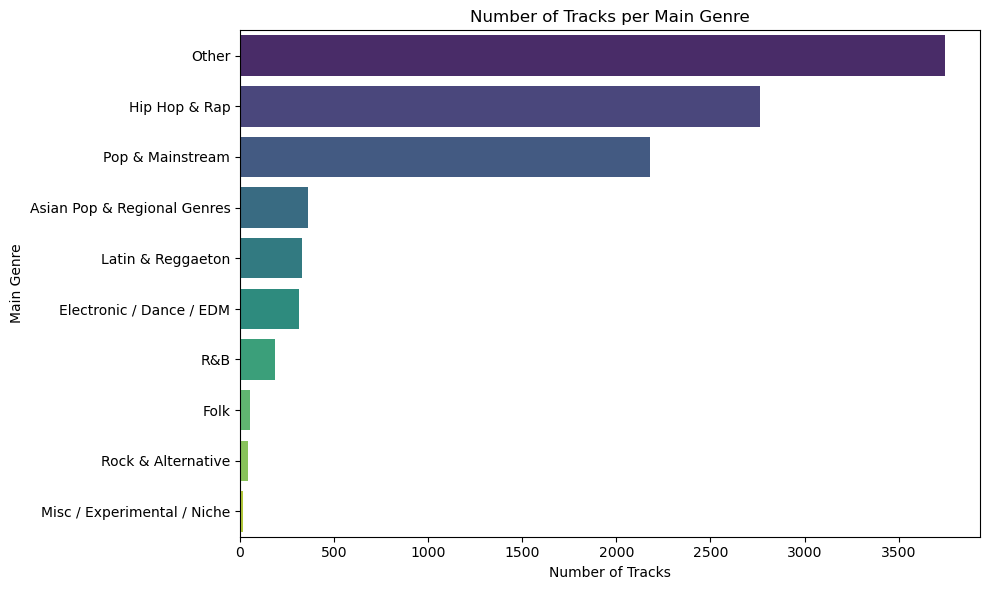

In [56]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_genres,
    y="main_genre",  # genres on y-axis
    x="count",       # counts on x-axis
    palette="viridis"
)

plt.title("Number of Tracks per Main Genre")
plt.xlabel("Number of Tracks")
plt.ylabel("Main Genre")
plt.tight_layout()
plt.savefig("sorted_genre_barchart_horizontal.png", dpi=300)
plt.show()